### 8. Genomför en klusteranalys på datasetet “hr_employee_data.xlsx”. Notera, i kapitel 4, uppgift 11, så använde vi left som den beroende variabeln 𝑦. Eftersom vi nu genomför en klusteranalys så modellerar vi inte med avseende på 𝑦 utan nu betraktar vi alla variabler som 𝑥. Fundera på vilka variabler du vill använda och hur det du skapar hade kunnat användas i verkligheten.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## Läs in data och välj variabler

`left` används inte som målvariabel i klusteranalysen. Den tas bort tillsammans med `Emp_Id`, eftersom ID-numret inte beskriver den anställde. Övriga variabler används som `x`: arbetsrelaterade mått, olyckor, befordran samt avdelning och lön.

In [8]:
df = pd.read_excel('../Kapetal-4/hr_employee_data.xlsx')

print(f'Rader och kolumner: {df.shape}')
print(f'Saknade värden: {df.isna().sum().sum()}')
display(df.head())

# left och Emp_Id ska inte påverka klustren.
X = df.drop(columns=['left', 'Emp_Id'])
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

print('Numeriska variabler:', numeric_features)
print('Kategoriska variabler:', categorical_features)


Rader och kolumner: (14999, 11)
Saknade värden: 0


,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


Numeriska variabler: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']
Kategoriska variabler: ['Department', 'salary']


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

X_prepared = preprocessor.fit_transform(X)
print('Form efter preprocessing:', X_prepared.shape)


Form efter preprocessing: (14999, 20)


## Välj antal kluster

Jag jämför `k=2` till `k=8`. Inertia visar hur kompakt klustren är och silhouette score mäter hur väl observationerna separeras. Ett högre silhouette score är bättre, men valet behöver också vara begripligt och användbart i verksamheten.

Utvärdering av antal kluster:


,antal_kluster,inertia,silhouette_score
0,2,108388.622,0.165
1,3,93534.608,0.172
2,4,80579.688,0.199
3,5,70601.567,0.202
4,6,64040.255,0.209
5,7,59998.737,0.187
6,8,56955.413,0.190


Högst silhouette score: 6 kluster (0.209)


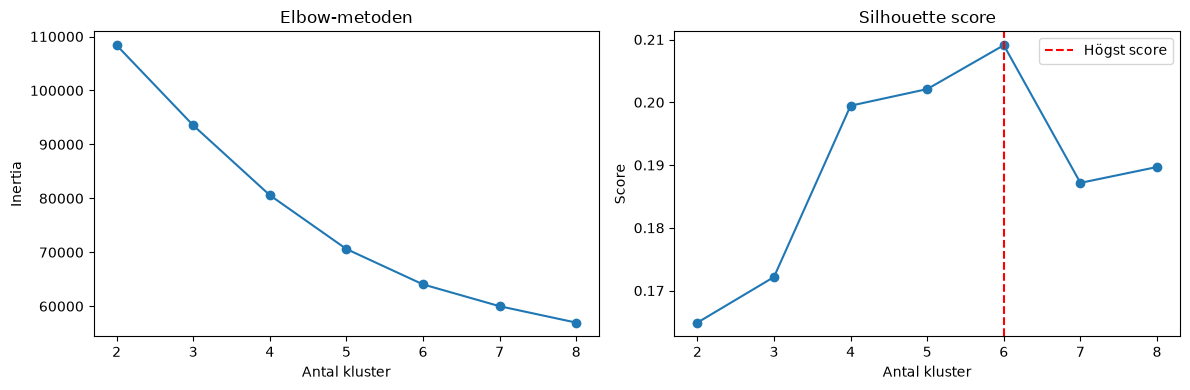

In [10]:
results = []

for cluster_count in range(2, 9):
    model = KMeans(n_clusters=cluster_count, n_init=10, random_state=42)
    labels = model.fit_predict(X_prepared)
    results.append({
        'antal_kluster': cluster_count,
        'inertia': model.inertia_,
        'silhouette_score': silhouette_score(X_prepared, labels),
    })

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['silhouette_score'].idxmax()]

print('Utvärdering av antal kluster:')
display(results_df.round(3))
print(
    f"Högst silhouette score: {int(best_row['antal_kluster'])} kluster "
    f"({best_row['silhouette_score']:.3f})"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(results_df['antal_kluster'], results_df['inertia'], marker='o')
axes[0].set(title='Elbow-metoden', xlabel='Antal kluster', ylabel='Inertia')

axes[1].plot(
    results_df['antal_kluster'],
    results_df['silhouette_score'],
    marker='o',
)
axes[1].set(
    title='Silhouette score',
    xlabel='Antal kluster',
    ylabel='Score',
)
axes[1].axvline(
    best_row['antal_kluster'],
    color='red',
    linestyle='--',
    label='Högst score',
)
axes[1].legend()
plt.tight_layout()
plt.show()


## Träna slutmodellen och profilera klustren

Jag använder sex kluster eftersom det gav högst silhouette score. Klusternumren har ingen inbördes rangordning: kluster 0 är inte bättre eller sämre än kluster 1.

In [11]:
best_k = int(best_row['antal_kluster'])
final_model = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df['cluster'] = final_model.fit_predict(X_prepared)

cluster_sizes = df['cluster'].value_counts().sort_index().rename('antal_anställda')
numeric_profile = df.groupby('cluster')[numeric_features].mean().round(2)
categorical_profile = df.groupby('cluster')[categorical_features].agg(
    lambda column: column.mode().iat[0]
)

print(f'Vald modell: KMeans med {best_k} kluster')
print('Antal anställda per kluster:')
display(cluster_sizes.to_frame())
print('Genomsnitt för numeriska variabler per kluster:')
display(numeric_profile)
print('Vanligaste kategorier per kluster:')
display(categorical_profile)


Vald modell: KMeans med 6 kluster
Antal anställda per kluster:


,antal_anställda
cluster,
0,1611
1,6287
2,1953
3,1710
4,3119
5,319


Genomsnitt för numeriska variabler per kluster:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
cluster,,,,,,,
0,0.16,0.81,5.71,251.94,4.24,0.03,0.0
1,0.75,0.75,3.80,207.39,2.82,0.00,0.0
2,0.66,0.71,3.73,197.30,3.21,1.00,0.0
3,0.75,0.83,4.25,223.89,6.17,0.05,0.0
4,0.46,0.54,2.62,151.93,3.14,0.00,0.0
5,0.66,0.71,3.75,199.85,4.17,0.24,1.0


Vanligaste kategorier per kluster:


,Department,salary
cluster,,
0,sales,low
1,sales,low
2,sales,low
3,sales,low
4,sales,low
5,sales,medium


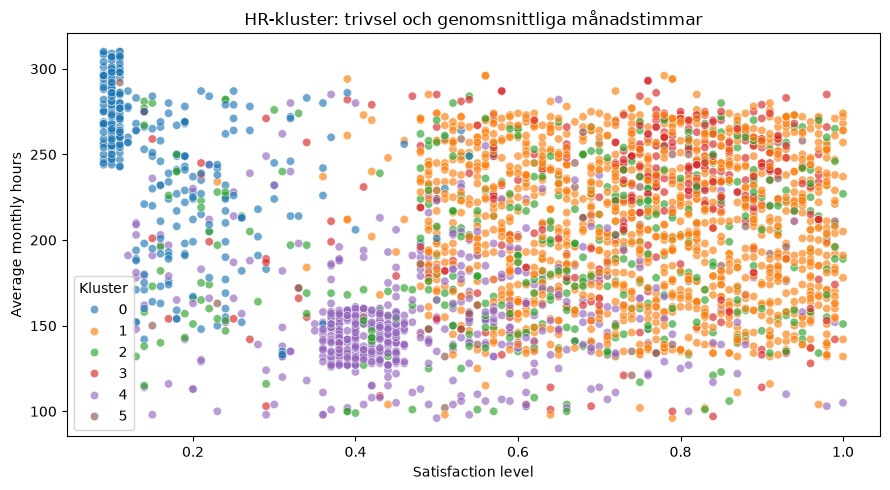

In [12]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df.sample(n=min(3000, len(df)), random_state=42),
    x='satisfaction_level',
    y='average_montly_hours',
    hue='cluster',
    palette='tab10',
    alpha=0.65,
)
plt.title('HR-kluster: trivsel och genomsnittliga månadstimmar')
plt.xlabel('Satisfaction level')
plt.ylabel('Average monthly hours')
plt.legend(title='Kluster')
plt.tight_layout()
plt.show()


## Hur analysen kan användas i verkligheten

Klustren kan användas som personalprofiler för att planera riktade HR-insatser. Ett kluster med låg trivsel och många arbetstimmar kan exempelvis prioriteras för arbetsmiljösamtal, medan ett kluster med lång anställningstid och få befordringar kan få tydligare utvecklings- och karriärvägar. Kluster med hög projektbelastning kan ge underlag för bemanning och resursfördelning.

Analysen beskriver likheter mellan anställda, men bevisar inte varför någon stannar eller slutar. Därför ska `left` inte användas för att skapa klustren och resultaten bör inte användas för automatiska beslut om enskilda personer. HR bör kontrollera profilerna tillsammans med kvalitativa samtal, följa förändringar över tid och säkerställa att åtgärderna inte missgynnar någon grupp.